In [ ]:
Constant Damping

step=0 mean neighbours = 1.90
step=10000 mean neighbours = 2.90
step=20000 mean neighbours = 2.90
step=30000 mean neighbours = 3.00
step=40000 mean neighbours = 4.00
step=50000 mean neighbours = 4.60
step=60000 mean neighbours = 3.90
step=70000 mean neighbours = 3.50
step=80000 mean neighbours = 3.70
step=90000 mean neighbours = 3.30
step=100000 mean neighbours = 4.20
step=110000 mean neighbours = 2.90
step=120000 mean neighbours = 5.20
step=130000 mean neighbours = 5.70
step=140000 mean neighbours = 5.40
step=150000 mean neighbours = 5.60
step=160000 mean neighbours = 4.80
step=170000 mean neighbours = 4.50
step=180000 mean neighbours = 5.30
step=190000 mean neighbours = 5.90


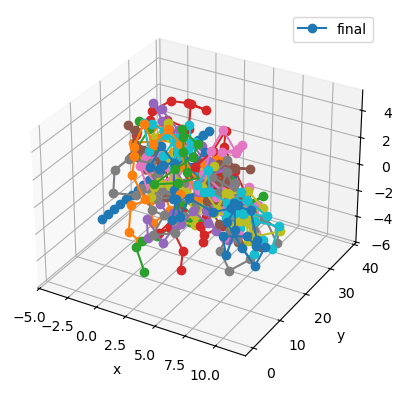

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

#//parameters//
N_beads =  20                      
dt = 5*1e-4
N_steps = 200000
gamma0 =0.5
KbT = 1
k = 100 * KbT
epsilon = 1
sigma = 0.8
r0= 2
cutoff = 3 * r0 / 2 
positions = np.zeros((N_steps, N_beads, 3))


# Initialization of string position along y axis


for i in range(N_beads):
    positions[0, i, 0] = 0
    positions[0, i, 1] = i * r0
    positions[0, i, 2] = 0


# //bond pairs
bond = []
for i in range(N_beads - 1):
    bond.append((i, i + 1))


# Function of Damping (sigmoid)


def gamma(z, ai, bi, li_val):
    
    arg = np.clip(-li_val * (z - r0), -500, 500)
    return ai / (1 + np.exp(arg)) + bi
    

# function for spring force

@njit(cache=True)
def spring_force(pos):
    F = np.zeros_like(pos)
    for i in range(N_beads - 1):
        dr = pos[i + 1] -    pos[i]
        r = np.linalg.norm(dr)
        rhat = dr / r
        f = - k * (r- r0) * rhat
        F[i] -= f
        F[i + 1] += f
    return F

# function for volume exclusion

@njit(cache=True)
def force_excluding_volume(pos):
    F = np.zeros_like(pos)
    rlim = 2 ** (1 / 6) * sigma
    for i in range(N_beads):
        for j in range(i + 2, N_beads): 
            dr = pos[j] - pos[i]
            r = np.linalg.norm(dr)
            if r < 1e-12:
                continue
            if r < rlim:
                rhat = dr / r
                force_mag = (24 * epsilon / r * (2 * (sigma / r) ** 12 - (sigma / r) ** 6))
                f = force_mag * rhat
                F[i] -= f
                F[j] += f
    return F


# figure in 3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# storage for neighbour tracking
meanlocal = []   # <-- added

# Simulation


for n in range(N_steps - 1):  
    pos = positions[n]
    dr_all = pos[:, None, :] - pos[None, :, :]
    dist = np.linalg.norm(dr_all, axis=2)
    n_local = np.sum((dist <= cutoff) & (dist > 0), axis=1)
    meanlocal.append(round(np.mean(n_local), 2))
    force = spring_force(pos) + force_excluding_volume(pos)
    noise = np.random.randn(N_beads, 3)
    #noise[:,2]=np.zeros(N_beads)  # Plot for 1D
    #noise[:,0]=np.zeros(N_beads)
    positions[n + 1] = (pos + (force / gamma0) * dt + np.sqrt(2 * KbT * dt / gamma0) * noise)
    if n % 10000 == 0:
        print(f"step={n}",f"mean neighbours = {np.mean(n_local):.2f}")
        ax.plot(positions[n, :, 0], positions[n, :, 1], positions[n, :, 2], '-o')#, #label=f"n={n}")


#3 D plot at 10000 step 
ax.plot(positions[-1, :, 0], positions[-1, :, 1], positions[-1, :, 2], '-o', label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.show()  

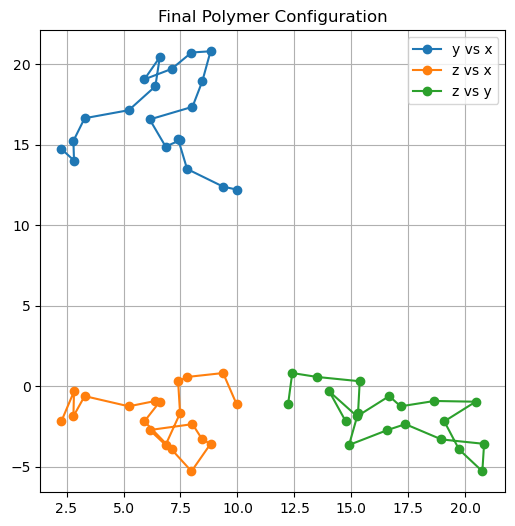

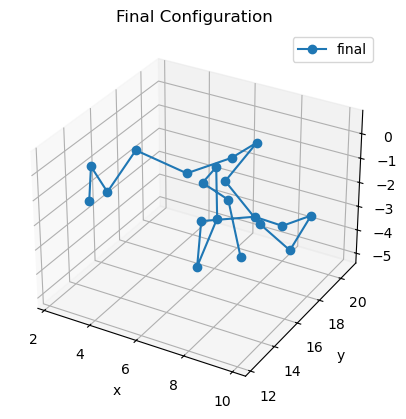

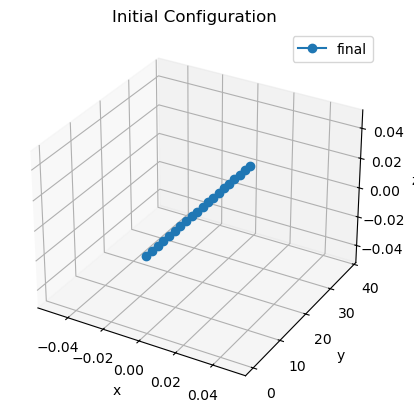

In [35]:
# 2D plots at final step

plt.figure(figsize=(6, 6))

plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 1],
    '-o',label="y vs x"
)
plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 2],
    '-o',label="z vs x"
)
plt.plot(
    positions[-1, :, 1],
    positions[-1, :, 2],
    '-o',label="z vs y"
)


#plt.xlabel("x")
#plt.ylabel("y")
plt.title("Final Polymer Configuration")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#3 D plot at 10000 step 
ax.plot(positions[-1, :, 0], positions[-1, :, 1], positions[-1, :, 2], '-o', label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Final Configuration")
ax.legend()
plt.show() 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#3 D plot at 10000 step 
ax.plot(positions[0, :, 0], positions[0, :, 1], positions[0, :, 2], '-o', label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Configuration")
ax.legend()
plt.show() 

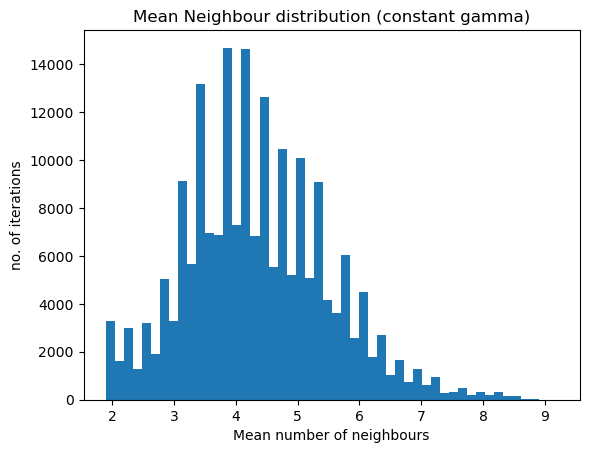

In [36]:
# ==========================================================
# NEIGHBOUR DISTRIBUTION PLOT (constant gamma case)
# ==========================================================
plt.figure()
plt.hist(meanlocal, bins=50)
plt.title("Mean Neighbour distribution (constant gamma)")
plt.xlabel("Mean number of neighbours")
plt.ylabel("no. of iterations")
plt.show()

In [37]:
t= np.mean(meanlocal)
p= np.std(meanlocal)
print(t,p)

4.3499687498437485 1.1648055075345345


In [ ]:
Radius of Gyration vs time Plot

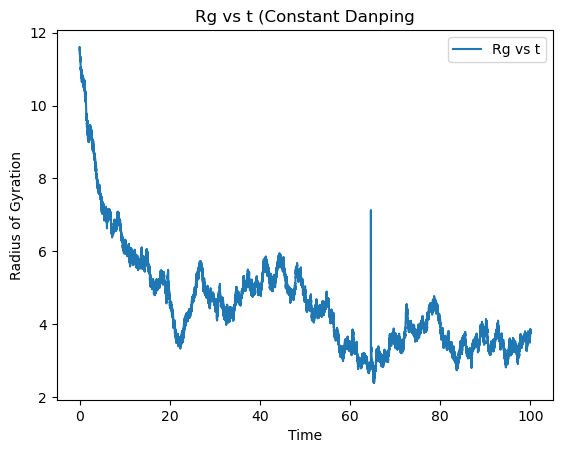

In [38]:
# Radius of gyration vs time graph for constant damping
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

time = np.arange(N_steps) * dt
rgcm = np.zeros(N_steps)

#@njit(cache=True)

for i in range(N_steps):

    xcml = np.zeros((1,3))
    q1 = 0

    # Calculate centre of mass
    for bead in range(N_beads):
        q1 += positions[i, bead]

    xcml = q1 / N_beads

    # Calculate Radius of Gyration
    Rg = 0
    sumdr = 0

    for t in range(N_beads):
        d1 = np.linalg.norm(positions[i, t, :] - xcml)
        d2 = d1**2
        sumdr += d2

    Rg = np.sqrt(sumdr / N_beads)

    rgcm[i] = Rg

plt.plot(time, rgcm, '-', label="Rg vs t")
plt.xlabel("Time")
plt.ylabel("Radius of Gyration")
plt.title("Rg vs t (Constant Danping")
plt.legend()
plt.show()
    
    

In [39]:
print(rgcm[0],rgcm[-1])

11.532562594670797 3.779499131469081


In [ ]:
Centre of mass Plot

<function matplotlib.pyplot.show(close=None, block=None)>

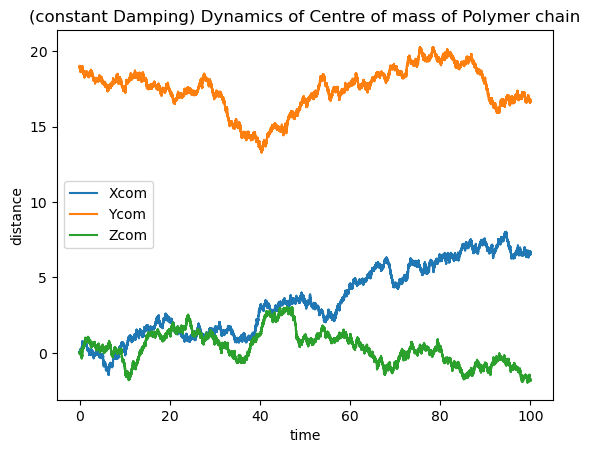

In [41]:
import numpy as np
time= np.arange(N_steps)*dt
xcm= np.zeros((N_steps,3))

for i in range(N_steps):
    q = np.zeros(3)
    for t in range(N_beads):
        q+=(positions[i,t])

    xcm[i]=q/N_beads

plt.plot(time,xcm[:,0],'-',label="Xcom")
plt.plot(time,xcm[:,1],'-',label="Ycom")
plt.plot(time,xcm[:,2],'-',label="Zcom")
plt.xlabel("time")
plt.ylabel("distance")
plt.title("(constant Damping) Dynamics of Centre of mass of Polymer chain")
plt.legend()

plt.show

In [ ]:
Ignore It

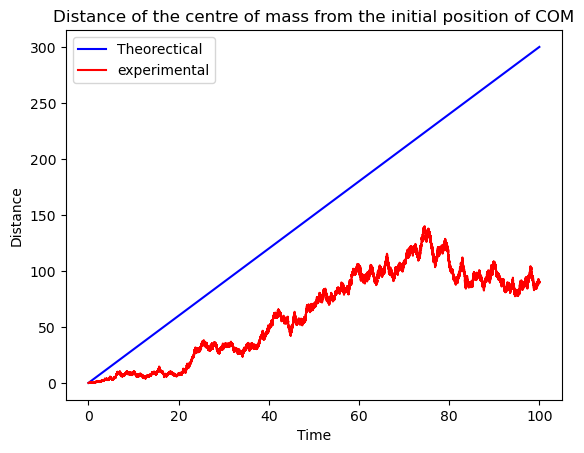

In [7]:
t= np.arange(N_steps)*dt
ini=np.mod
msd=[]
#msd=np.mean(xcm**2)
for i in range(N_steps):
    c=np.sum((xcm[i]-xcm[0])**2)

    msd.append(c)

msd2 = np.sum((xcm - xcm[0])**2, axis=1)

plt.plot(t,6*0.5*t,'-',color='blue',label="Theorectical")
plt.plot(t,msd,'-',color='red',label="experimental")
plt.legend()
plt.xlabel("Time")
plt.title("Distance of the centre of mass from the initial position of COM")
plt.ylabel("Distance")
plt.show()
    

In [ ]:
End to End Distance

In [42]:
#end to end distance of the polymer REE Calculation ( Constant case)
Ree=positions[-1,0,:]-positions[-1,-1,:]
dist= np.linalg.norm(Ree)
print(dist)

8.166734694609694


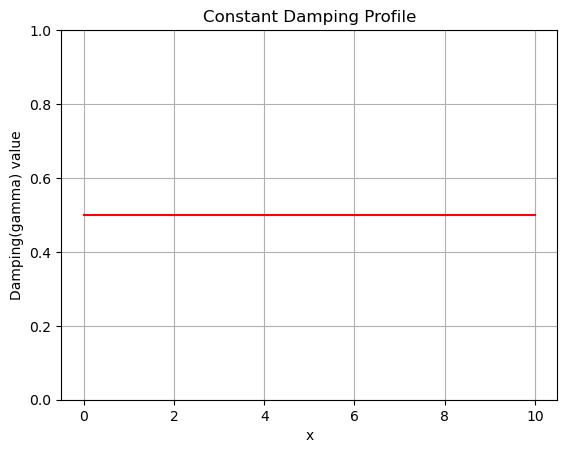

In [2]:
import numpy as np
import matplotlib.pyplot as plt
x=np.linspace(0,10,1000)
plt.plot(x,np.full_like(x,0.5),'-',color="red")
plt.xlabel("x")
plt.ylabel("Damping(gamma) value")
plt.title("Constant Damping Profile")
plt.ylim(0,1)
plt.grid(True)
plt.show()

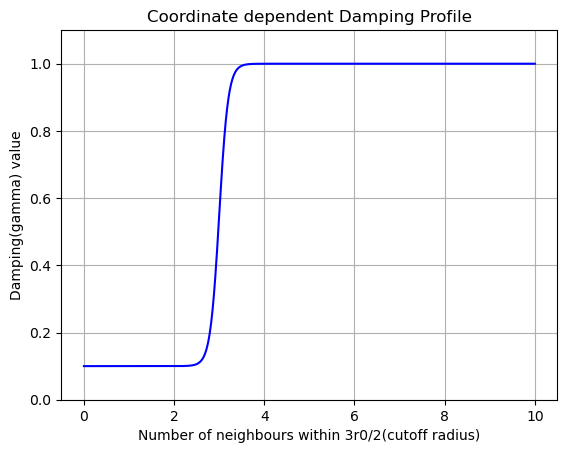

In [5]:
x=np.linspace(0,10,1000)
plt.plot(x,(0.9 / (1 + np.exp(-10 * (x - 3))) )+ 0.1,'-',color="blue")
plt.xlabel("Number of neighbours within 3r0/2(cutoff radius)")
plt.ylabel("Damping(gamma) value")
plt.title("Coordinate dependent Damping Profile")
plt.ylim(0,1.1)
plt.grid(True)
plt.show()

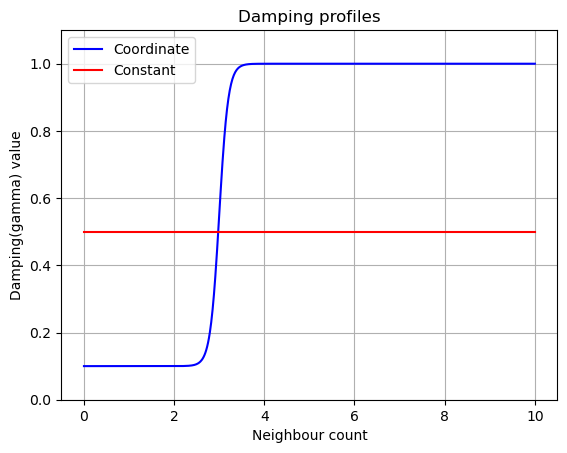

In [6]:
x=np.linspace(0,10,1000)
plt.plot(x,(0.9 / (1 + np.exp(-10 * (x - 3))) )+ 0.1,'-',color="blue",label="Coordinate")
plt.plot(x,np.full_like(x,0.5),'-',color="red",label="Constant")
plt.xlabel("Neighbour count")
plt.ylabel("Damping(gamma) value")
plt.title("Damping profiles")
plt.ylim(0,1.1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
Coordinate dependent damping case

step = 0 mean neighbours = 1.90 mean gamma = 0.10
step = 10000 mean neighbours = 4.00 mean gamma = 0.75
step = 20000 mean neighbours = 4.90 mean gamma = 0.95
step = 30000 mean neighbours = 6.20 mean gamma = 0.84
step = 40000 mean neighbours = 5.40 mean gamma = 0.98
step = 50000 mean neighbours = 5.90 mean gamma = 0.89
step = 60000 mean neighbours = 6.50 mean gamma = 0.93
step = 70000 mean neighbours = 7.60 mean gamma = 0.93
step = 80000 mean neighbours = 9.80 mean gamma = 1.00
step = 90000 mean neighbours = 7.20 mean gamma = 0.93
step = 100000 mean neighbours = 8.30 mean gamma = 1.00
step = 110000 mean neighbours = 6.40 mean gamma = 0.95
step = 120000 mean neighbours = 7.60 mean gamma = 1.00
step = 130000 mean neighbours = 5.30 mean gamma = 0.89
step = 140000 mean neighbours = 6.50 mean gamma = 0.93
step = 150000 mean neighbours = 5.20 mean gamma = 0.86
step = 160000 mean neighbours = 8.40 mean gamma = 1.00
step = 170000 mean neighbours = 8.10 mean gamma = 0.98
step = 180000 mean neigh

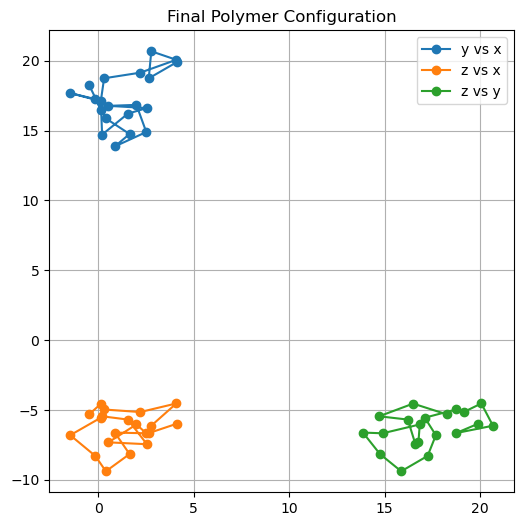

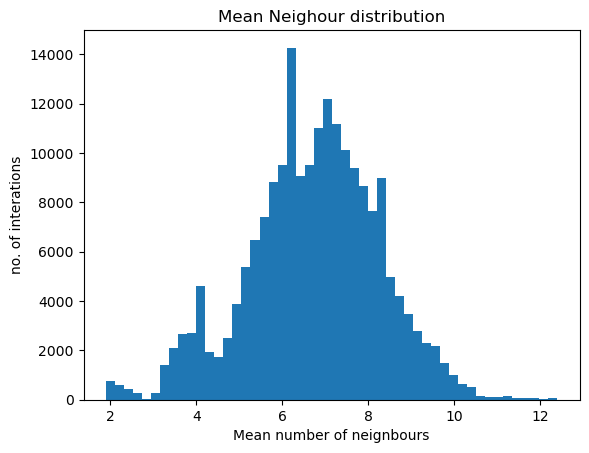

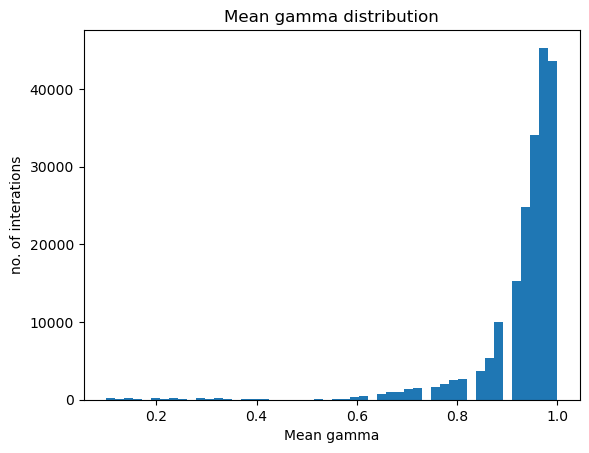

In [18]:
# simulation for n dependent gamma for a chain of 20 beads
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# ==========================================================
# PARAMETERS
# ==========================================================

N_beads = 20
dt = 5e-4
N_steps = 200000

KbT = 1.0
k = 100 * KbT

epsilon = 1.0
sigma = 0.8
r0 = 2.0

# gamma(n) parameters
a = 0.9
b = 0.1
lam = 10
nc = 3.0

cutoff = 3 * r0 / 2

# ==========================================================
# STORAGE
# ==========================================================

positions = np.zeros((N_steps + 1, N_beads, 3))

# ==========================================================
# INITIAL CONFIGURATION
# ==========================================================

for i in range(N_beads):
    positions[0, i, 0] = 0
    positions[0, i, 1] = i * r0
    positions[0, i, 2] = 0

# ==========================================================
# SPRING FORCE
# ==========================================================
# <-- only change here: added @njit(cache=True)

@njit(cache=True)
def spring_force(pos):

    F = np.zeros_like(pos)

    for i in range(N_beads - 1):

        dr = pos[i + 1] - pos[i]

        r = np.linalg.norm(dr)

        if r < 1e-12:
            continue

        rhat = dr / r

        f = -k * (r - r0) * rhat

        F[i] -= f
        F[i + 1] += f

    return F

# ==========================================================
# EXCLUDED VOLUME FORCE (WCA)
# ==========================================================
# <-- only change here: added @njit(cache=True)
# this is the one that was eating ~85% of your runtime
# (872,000 calls to np.linalg.norm in a Python loop, for 2000 steps alone)

@njit(cache=True)
def excluded_volume_force(pos):

    F = np.zeros_like(pos)

    rlim = 2 ** (1 / 6) * sigma

    for i in range(N_beads):

        for j in range(i + 2, N_beads):

            dr = pos[j] - pos[i]

            r = np.linalg.norm(dr)

            if r < 1e-12:
                continue

            if r < rlim:

                rhat = dr / r

                force_mag = (
                    24 * epsilon / r
                    * (2 * (sigma / r) ** 12
                       - (sigma / r) ** 6)
                )

                f = force_mag * rhat

                F[i] -= f
                F[j] += f

    return F

# ==========================================================
# GAMMA FUNCTION
# ==========================================================
# left as plain Python/NumPy -- it's vectorized over all beads
# already and only runs once per step, so it was never the bottleneck

def gamma_func(n):

    return (a / (1 + np.exp(-lam * (n - nc))) )+ b

# ==========================================================
# MAIN SIMULATION LOOP
# ==========================================================
# unchanged from your original
meanlocal=[]
meangamma=[]
for step in range(N_steps):

    pos = positions[step]

    # ------------------------------------------------------
    # VECTORIZED NEIGHBOUR COUNTING
    # ------------------------------------------------------

    dr = pos[:, None, :] - pos[None, :, :]

    dist = np.linalg.norm(dr, axis=2)

    n_local = np.sum(
        (dist <= cutoff) & (dist > 0),
        axis=1
    )

    # ------------------------------------------------------
    # GAMMA FOR EACH BEAD
    # ------------------------------------------------------

    gamma_arr = gamma_func(n_local)[:, None]

    # ------------------------------------------------------
    # TOTAL FORCE
    # ------------------------------------------------------

    force = (
        spring_force(pos)
        + excluded_volume_force(pos)
    )

    # ------------------------------------------------------
    # NOISE
    # ------------------------------------------------------

    noise = np.random.randn(N_beads, 3)

    # Uncomment if you want only y-motion
    # noise[:, 0] = 0
    # noise[:, 2] = 0

    # ------------------------------------------------------
    # EULER-MARUYAMA STEP
    # ------------------------------------------------------

    positions[step + 1] = (
        pos
        + (force / gamma_arr) * dt
        + np.sqrt(2 * KbT * dt / gamma_arr) * noise
    )

    # ------------------------------------------------------
    # DEBUG PRINT
    # ------------------------------------------------------

    if step % 10000 == 0:

        print(
            f"step = {step}",
            f"mean neighbours = {np.mean(n_local):.2f}",
            f"mean gamma = {np.mean(gamma_arr):.2f}"
        )
    mnl=round(np.mean(n_local),2)
    mg=round(np.mean(gamma_arr),2)
    meanlocal.append(mnl) 
    meangamma.append(mg)
# ==========================================================
# FINAL CONFIGURATION PLOT
# ==========================================================

plt.figure(figsize=(6, 6))

plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 1],
    '-o',label="y vs x"
)
plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 2],
    '-o',label="z vs x"
)                
plt.plot(
    positions[-1, :, 1],
    positions[-1, :, 2],
    '-o',label="z vs y"
)


#plt.xlabel("x")
#plt.ylabel("y")
plt.title("Final Polymer Configuration")
plt.legend()
plt.grid(True)
plt.show()

#distribution of mean local neighbours
plt.hist(meanlocal,bins=50)
plt.title("Mean Neighour distribution")
plt.xlabel("Mean number of neignbours")
plt.ylabel("no. of interations")
plt.show()

#distribution of gamma
plt.hist(meangamma,bins=50)
plt.title("Mean gamma distribution")
plt.xlabel("Mean gamma")
plt.ylabel("no. of interations")
plt.show()

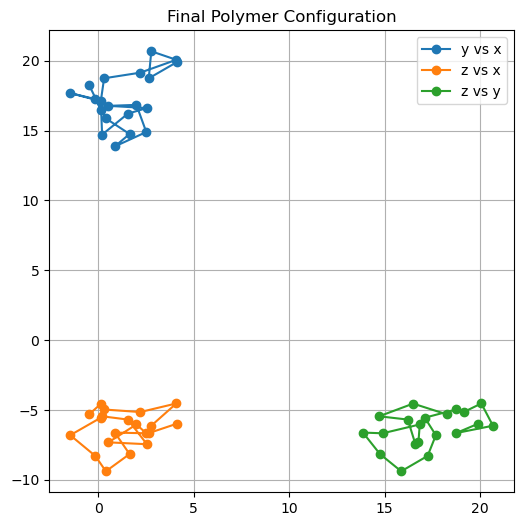

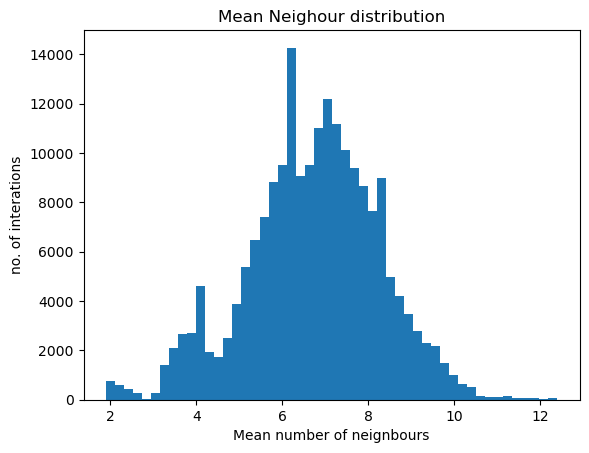

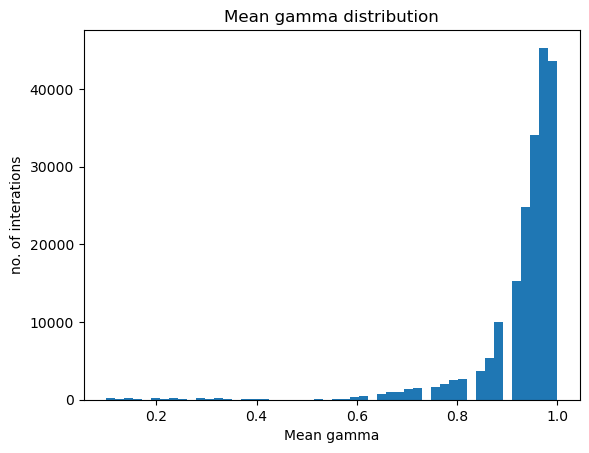

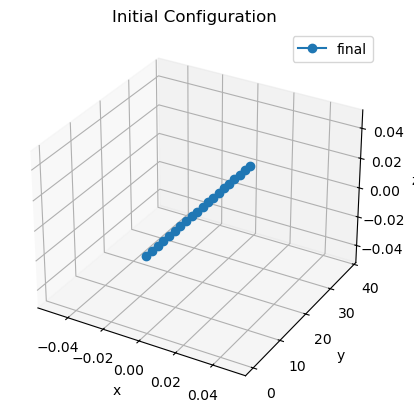

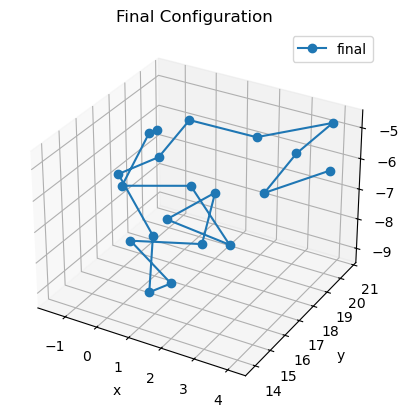

In [27]:
# ==========================================================
# FINAL CONFIGURATION PLOT
# ==========================================================

plt.figure(figsize=(6, 6))

plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 1],
    '-o',label="y vs x"
)
plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 2],
    '-o',label="z vs x"
)                
plt.plot(
    positions[-1, :, 1],
    positions[-1, :, 2],
    '-o',label="z vs y"
)


#plt.xlabel("x")
#plt.ylabel("y")
plt.title("Final Polymer Configuration")
plt.legend()
plt.grid(True)
plt.show()

#distribution of mean local neighbours
plt.hist(meanlocal,bins=50)
plt.title("Mean Neighour distribution")
plt.xlabel("Mean number of neignbours")
plt.ylabel("no. of interations")
plt.show()

#distribution of gamma
plt.hist(meangamma,bins=50)
plt.title("Mean gamma distribution")
plt.xlabel("Mean gamma")
plt.ylabel("no. of interations")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#3 D plot at 10000 step 
ax.plot(positions[0, :, 0], positions[0, :, 1], positions[0, :, 2], '-o', label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Initial Configuration")
ax.legend()
plt.show() 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
#3 D plot at 10000 step 
ax.plot(positions[-1, :, 0], positions[-1, :, 1], positions[-1, :, 2], '-o', label="final")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Final Configuration")
ax.legend()
plt.show()

In [21]:
t= np.mean(meanlocal)
p=np.std(meanlocal)
print(t,p)

6.715269500000001 1.5507016451818674


In [ ]:
Radius of Gyration plot

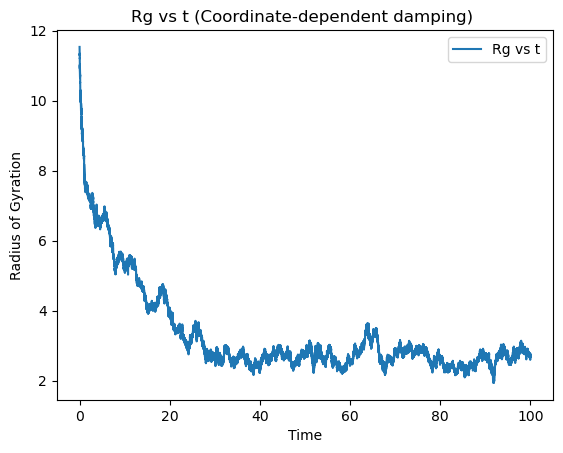

In [31]:
# Radius of gyration vs time graph
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(N_steps) * dt
rgcm = np.zeros(N_steps)

#@njit(cache=True)
for i in range(N_steps):

    xcml = np.zeros((1,3))
    q1 = 0

    # Calculate centre of mass
    for bead in range(N_beads):
        q1 += positions[i, bead]

    xcml = q1 / N_beads

    # Calculate Radius of Gyration
    Rg = 0
    sumdr = 0

    for t in range(N_beads):
        d1 = np.linalg.norm(positions[i, t, :] - xcml)
        d2 = d1**2
        sumdr += d2

    Rg = np.sqrt(sumdr / N_beads)

    rgcm[i] = Rg

plt.plot(time, rgcm, '-', label="Rg vs t")
plt.xlabel("Time")
plt.ylabel("Radius of Gyration")
plt.title("Rg vs t (Coordinate-dependent damping) ")
plt.legend()
plt.show()
    
    

In [32]:
print(rgcm[0],rgcm[-1])


11.532562594670797 2.701444852205799


In [ ]:
Centre of mass Plot

<function matplotlib.pyplot.show(close=None, block=None)>

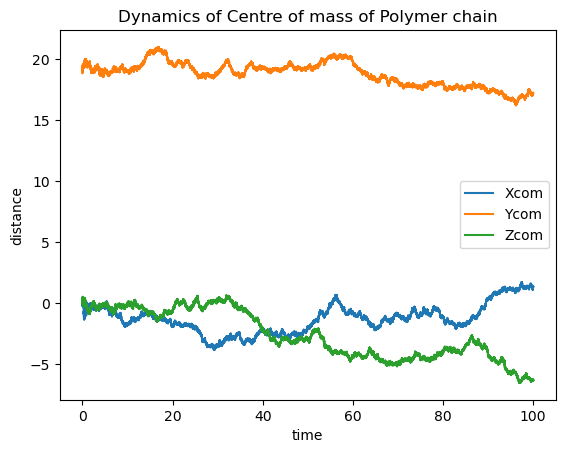

In [30]:
import numpy as np
time= np.arange(N_steps)*dt
xcm= np.zeros((N_steps,3))

for i in range(N_steps):
    q = np.zeros(3)
    for t in range(N_beads):
        q+=(positions[i,t])

    xcm[i]=q/N_beads

plt.plot(time,xcm[:,0],'-',label="Xcom")
plt.plot(time,xcm[:,1],'-',label="Ycom")
plt.plot(time,xcm[:,2],'-',label="Zcom")
plt.xlabel("time")
plt.title("Dynamics of Centre of mass of Polymer chain")
plt.ylabel("distance")
plt.legend()

plt.show

In [ ]:
Ignore it

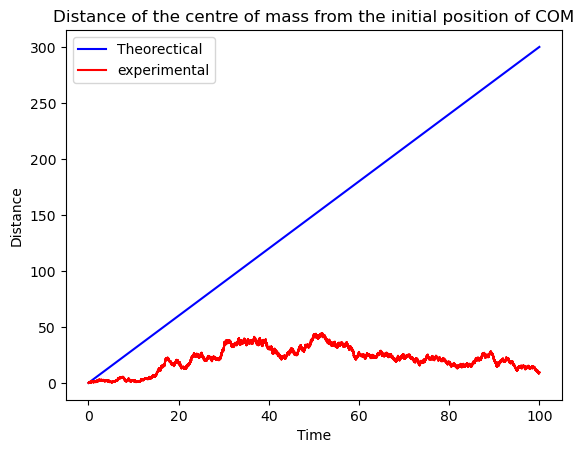

In [16]:
t= np.arange(N_steps)*dt
ini=np.mod

msd=[]
for i in range(N_steps):
    c=np.sum((xcm[i]-xcm[0])**2)

    msd.append(c)

msd2 = np.sum((xcm - xcm[0])**2, axis=1)

plt.plot(t,6*0.5*t,'-',color='blue',label="Theorectical")
plt.plot(t,msd2,'-',color='red',label="experimental")
plt.legend()
plt.xlabel("Time")
plt.title("Distance of the centre of mass from the initial position of COM")
plt.ylabel("Distance")
plt.show()
    

In [ ]:
End to End distance 

In [33]:
#end to end distance of the polymer REE Calculation (Coordinate dependent case)
Ree=positions[-1,0,:]-positions[-1,-1,:]
dist= np.linalg.norm(Ree)
print(dist)

4.933008561188793


In [ ]:
MSD Plot of centre of mass ( constant Damping case )

trajectory=0
step=0
step=10000
step=20000
step=30000
step=40000
step=50000
step=60000
step=70000
step=80000
step=90000
step=100000
step=110000
step=120000
step=130000
step=140000
step=150000
step=160000
step=170000
step=180000
step=190000
trajectory=1
step=0
step=10000
step=20000
step=30000
step=40000
step=50000
step=60000
step=70000
step=80000
step=90000
step=100000
step=110000
step=120000
step=130000
step=140000
step=150000
step=160000
step=170000
step=180000
step=190000
trajectory=2
step=0
step=10000
step=20000
step=30000
step=40000
step=50000
step=60000
step=70000
step=80000
step=90000
step=100000
step=110000
step=120000
step=130000
step=140000
step=150000
step=160000
step=170000
step=180000
step=190000
trajectory=3
step=0
step=10000
step=20000
step=30000
step=40000
step=50000
step=60000
step=70000
step=80000
step=90000
step=100000
step=110000
step=120000
step=130000
step=140000
step=150000
step=160000
step=170000
step=180000
step=190000
trajectory=4
step=0
step=10000
step=20000
st

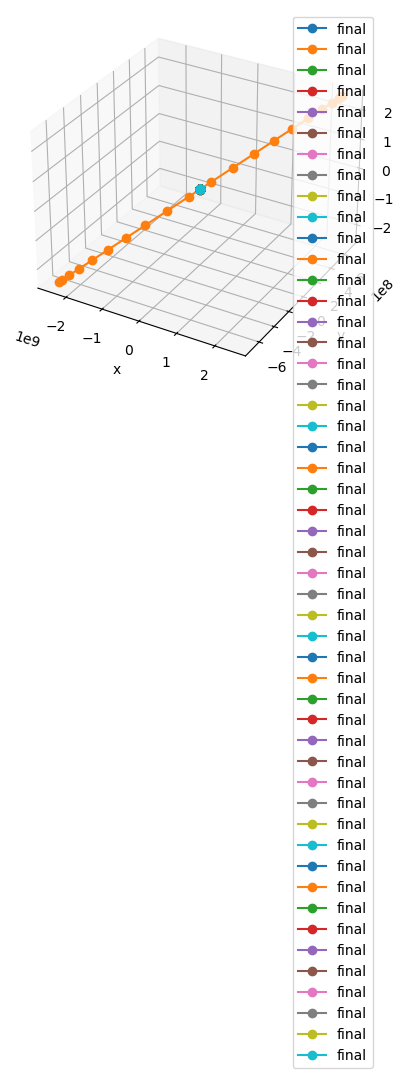

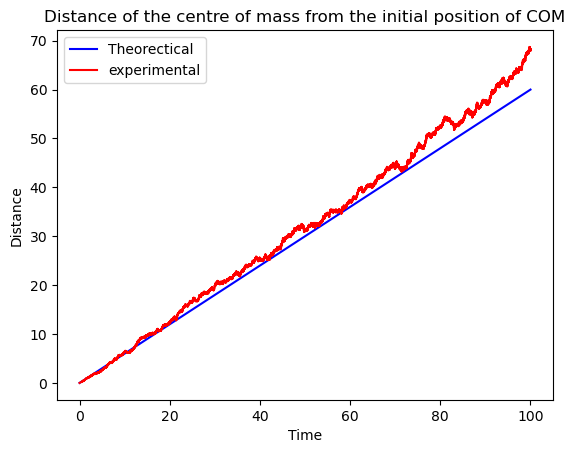

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
#//parameters//
N_beads =  20                      
dt = 5*1e-4
N_steps = 200000
gamma0 =0.5
KbT = 1
k = 100 * KbT
epsilon = 1
sigma = 0.8
r0= 2
N_traj = 50                                          # <-- added
xcm_all = np.zeros((N_traj, N_steps, 3))             # <-- added

positions = np.zeros((N_steps, N_beads, 3))
# Initialization of string position along y axis
for i in range(N_beads):
    positions[0, i, 0] = 0
    positions[0, i, 1] = i * r0
    positions[0, i, 2] = 0
# //bond pairs
bond = []
for i in range(N_beads - 1):
    bond.append((i, i + 1))
# Function of Damping (sigmoid)
def gamma(z, ai, bi, li_val):
    
    arg = np.clip(-li_val * (z - r0), -500, 500)
    return ai / (1 + np.exp(arg)) + bi
    
# function for spring force
@njit(cache=True)
def spring_force(pos):
    F = np.zeros_like(pos)
    for i in range(N_beads - 1):
        dr = pos[i + 1] -    pos[i]
        r = np.linalg.norm(dr)
        rhat = dr / r
        f = - k * (r- r0) * rhat
        F[i] -= f
        F[i + 1] += f
    return F
# function for volume exclusion
@njit(cache=True)
def force_excluding_volume(pos):
    F = np.zeros_like(pos)
    rlim = 2 ** (1 / 6) * sigma
    for i in range(N_beads):
        for j in range(i + 2, N_beads): 
            dr = pos[j] - pos[i]
            r = np.linalg.norm(dr)
            if r < 1e-12:
                continue
            if r < rlim:
                rhat = dr / r
                force_mag = (24 * epsilon / r * (2 * (sigma / r) ** 12 - (sigma / r) ** 6))
                f = force_mag * rhat
                F[i] -= f
                F[j] += f
    return F
# figure in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for traj in range(N_traj):                          # <-- added
    print(f"trajectory={traj}")                      # <-- added
    # Simulation
    for n in range(N_steps - 1):  
        pos = positions[n]
        force = spring_force(pos) + force_excluding_volume(pos)
        noise = np.random.randn(N_beads, 3)
        #noise[:,2]=np.zeros(N_beads)  # Plot for 1D
        #noise[:,0]=np.zeros(N_beads)
        positions[n + 1] = (pos + (force / gamma0) * dt + np.sqrt(2 * KbT * dt / gamma0) * noise)
        if n % 10000 == 0:
            print(f"step={n}")
            ax.plot(positions[n, :, 0], positions[n, :, 1], positions[n, :, 2], '-o')#, #label=f"n={n}")
    #3 D plot at 10000 step 
    ax.plot(positions[-1, :, 0], positions[-1, :, 1], positions[-1, :, 2], '-o', label="final")

    xcm_all[traj] = positions.mean(axis=1)           # <-- added (replaces old xcm loop, per trajectory)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.show()   

import numpy as np
time= np.arange(N_steps)*dt

msd_per_traj = np.sum((xcm_all - xcm_all[:, 0:1, :])**2, axis=2)   # <-- added
msd = msd_per_traj.mean(axis=0)                                    # <-- added

D = KbT / gamma0                                                    # <-- added
D_com = D / N_beads                                                 # <-- added

plt.plot(time, 6*D_com*time,'-',color='blue',label="Theorectical")  # <-- changed (uses D_com instead of hardcoded 0.5)
plt.plot(time, msd,'-',color='red',label="experimental")            # <-- changed (uses averaged msd)
plt.legend()
plt.xlabel("Time")
plt.title("Distance of the centre of mass from the initial position of COM")
plt.ylabel("Distance")
plt.show()

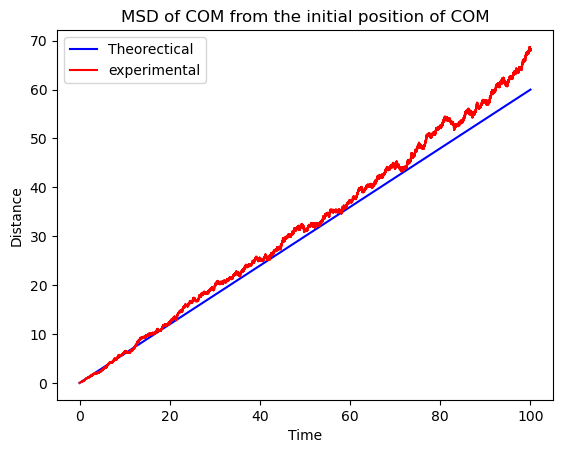

In [2]:
plt.plot(time, 6*D_com*time,'-',color='blue',label="Theorectical")  # <-- changed (uses D_com instead of hardcoded 0.5)
plt.plot(time, msd,'-',color='red',label="experimental")            # <-- changed (uses averaged msd)
plt.legend()
plt.xlabel("Time")
plt.title("MSD of COM from the initial position of COM")
plt.ylabel("Distance")
plt.show()

In [ ]:
MSD plot of Center Of Mass ( Coordinate dependent damping)

trajectory = 0
step = 0 mean neighbours = 1.90 mean gamma = 0.10
step = 10000 mean neighbours = 4.00 mean gamma = 0.75
step = 20000 mean neighbours = 4.00 mean gamma = 0.80
step = 30000 mean neighbours = 5.50 mean gamma = 0.87
step = 40000 mean neighbours = 5.60 mean gamma = 0.91
step = 50000 mean neighbours = 4.80 mean gamma = 0.89
step = 60000 mean neighbours = 5.10 mean gamma = 0.93
step = 70000 mean neighbours = 6.90 mean gamma = 0.91
step = 80000 mean neighbours = 8.80 mean gamma = 0.98
step = 90000 mean neighbours = 6.50 mean gamma = 0.93
step = 100000 mean neighbours = 5.70 mean gamma = 0.89
step = 110000 mean neighbours = 5.70 mean gamma = 0.91
step = 120000 mean neighbours = 9.30 mean gamma = 1.00
step = 130000 mean neighbours = 7.50 mean gamma = 0.98
step = 140000 mean neighbours = 8.80 mean gamma = 1.00
step = 150000 mean neighbours = 8.10 mean gamma = 1.00
step = 160000 mean neighbours = 6.20 mean gamma = 0.93
step = 170000 mean neighbours = 7.20 mean gamma = 0.95
step = 18

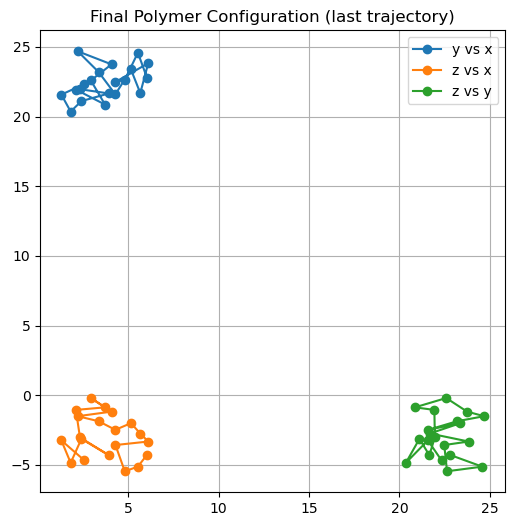

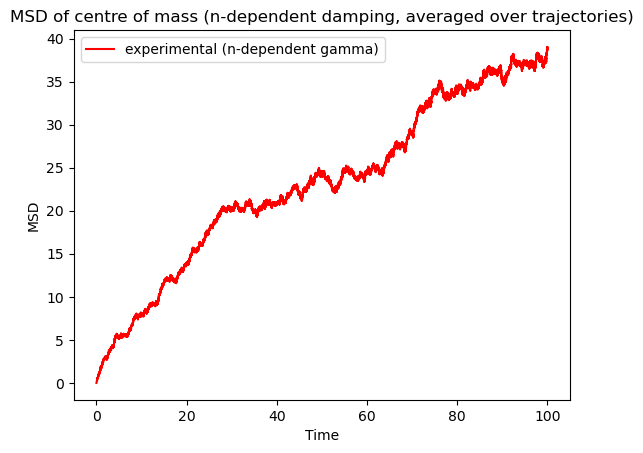

In [30]:


# simulation for n dependent gamma for a chain of 20 beads
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# ==========================================================
# PARAMETERS
# ==========================================================

N_beads = 20
dt = 5e-4
N_steps = 200000

KbT = 1.0
k = 100 * KbT

epsilon = 1.0
sigma = 0.8
r0 = 2.0

# gamma(n) parameters
a = 0.9
b = 0.1
lam = 10
nc = 3.0

cutoff = 3 * r0 / 2

N_traj = 20                                            # <-- added
xcm_all = np.zeros((N_traj, N_steps + 1, 3))           # <-- added (N_steps+1 to match your positions array length)

# ==========================================================
# STORAGE
# ==========================================================

positions = np.zeros((N_steps + 1, N_beads, 3))

# ==========================================================
# SPRING FORCE
# ==========================================================

@njit(cache=True)
def spring_force(pos):

    F = np.zeros_like(pos)

    for i in range(N_beads - 1):

        dr = pos[i + 1] - pos[i]

        r = np.linalg.norm(dr)

        if r < 1e-12:
            continue

        rhat = dr / r

        f = -k * (r - r0) * rhat

        F[i] -= f
        F[i + 1] += f

    return F

# ==========================================================
# EXCLUDED VOLUME FORCE (WCA)
# ==========================================================

@njit(cache=True)
def excluded_volume_force(pos):

    F = np.zeros_like(pos)

    rlim = 2 ** (1 / 6) * sigma

    for i in range(N_beads):

        for j in range(i + 2, N_beads):

            dr = pos[j] - pos[i]

            r = np.linalg.norm(dr)

            if r < 1e-12:
                continue

            if r < rlim:

                rhat = dr / r

                force_mag = (
                    24 * epsilon / r
                    * (2 * (sigma / r) ** 12
                       - (sigma / r) ** 6)
                )

                f = force_mag * rhat

                F[i] -= f
                F[j] += f

    return F

# ==========================================================
# GAMMA FUNCTION
# ==========================================================

def gamma_func(n):

    return (a / (1 + np.exp(-lam * (n - nc)))) + b

# ==========================================================
# MAIN SIMULATION LOOP
# ==========================================================

for traj in range(N_traj):                            # <-- added

    print(f"trajectory = {traj}")                      # <-- added

    # ------------------------------------------------------
    # INITIAL CONFIGURATION (re-set each trajectory)        # <-- added
    # ------------------------------------------------------

    positions[:] = 0                                    # <-- added (clears previous trajectory's data)
    for i in range(N_beads):                             # <-- added
        positions[0, i, 0] = 0                           # <-- added
        positions[0, i, 1] = i * r0                       # <-- added
        positions[0, i, 2] = 0                            # <-- added

    for step in range(N_steps):

        pos = positions[step]

        # ------------------------------------------------------
        # VECTORIZED NEIGHBOUR COUNTING
        # ------------------------------------------------------

        dr = pos[:, None, :] - pos[None, :, :]

        dist = np.linalg.norm(dr, axis=2)

        n_local = np.sum(
            (dist <= cutoff) & (dist > 0),
            axis=1
        )

        # ------------------------------------------------------
        # GAMMA FOR EACH BEAD
        # ------------------------------------------------------

        gamma_arr = gamma_func(n_local)[:, None]

        # ------------------------------------------------------
        # TOTAL FORCE
        # ------------------------------------------------------

        force = (
            spring_force(pos)
            + excluded_volume_force(pos)
        )

        # ------------------------------------------------------
        # NOISE
        # ------------------------------------------------------

        noise = np.random.randn(N_beads, 3)

        # Uncomment if you want only y-motion
        # noise[:, 0] = 0
        # noise[:, 2] = 0

        # ------------------------------------------------------
        # EULER-MARUYAMA STEP
        # ------------------------------------------------------

        positions[step + 1] = (
            pos
            + (force / gamma_arr) * dt
            + np.sqrt(2 * KbT * dt / gamma_arr) * noise
        )

        # ------------------------------------------------------
        # DEBUG PRINT
        # ------------------------------------------------------

        if step % 10000 == 0:

            print(
                f"step = {step}",
                f"mean neighbours = {np.mean(n_local):.2f}",
                f"mean gamma = {np.mean(gamma_arr):.2f}"
            )

    xcm_all[traj] = positions.mean(axis=1)              # <-- added (COM of this trajectory)

# ==========================================================
# FINAL CONFIGURATION PLOT (last trajectory only)
# ==========================================================

plt.figure(figsize=(6, 6))

plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 1],
    '-o', label="y vs x"
)
plt.plot(
    positions[-1, :, 0],
    positions[-1, :, 2],
    '-o', label="z vs x"
)
plt.plot(
    positions[-1, :, 1],
    positions[-1, :, 2],
    '-o', label="z vs y"
)

plt.title("Final Polymer Configuration (last trajectory)")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# MSD OF CENTRE OF MASS, AVERAGED OVER TRAJECTORIES          # <-- added block
# ==========================================================

time = np.arange(N_steps + 1) * dt                                        # <-- added

msd_per_traj = np.sum((xcm_all - xcm_all[:, 0:1, :])**2, axis=2)          # <-- added
msd = msd_per_traj.mean(axis=0)                                            # <-- added

plt.figure()
plt.plot(time, msd, '-', color='red', label="experimental (n-dependent gamma)")   # <-- added
plt.legend()
plt.xlabel("Time")
plt.ylabel("MSD")
plt.title("MSD of centre of mass (n-dependent damping, averaged over trajectories)")
plt.show()

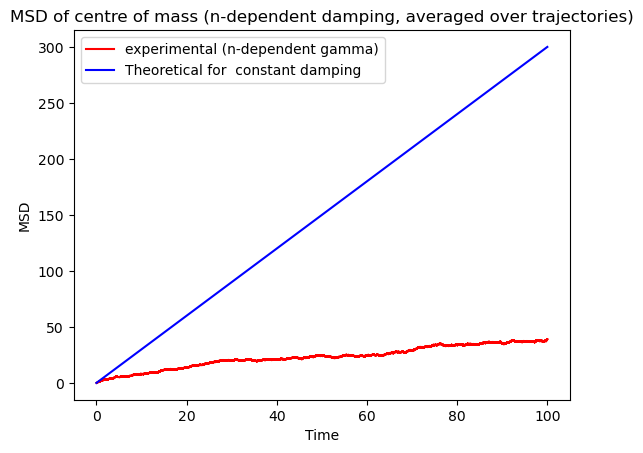

In [31]:
plt.figure()
plt.plot(time, msd, '-', color='red', label="experimental (n-dependent gamma)")   # <-- added
plt.plot(time,6*0.5*time,color='blue',label="Theoretical for  constant damping")
plt.legend()
plt.xlabel("Time")
plt.ylabel("MSD")
plt.title("MSD of centre of mass (n-dependent damping, averaged over trajectories)")
plt.show()